In [83]:
import pandas as pd
import re
import string
from datasets import load_dataset
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

pd.set_option('display.max_colwidth', None)

In [84]:
ds = load_dataset("avsolatorio/mteb-emotion-avs_triplets")

In [85]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text', 'idx', 'query_idx', 'positive_idx', 'negative_idx'],
        num_rows: 16000
    })
})

In [86]:
ds.set_format(type='pandas')

In [87]:
df = ds['train'][:]

In [88]:
df.head()

,text,label,label_text,idx,query_idx,positive_idx,negative_idx
0,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish,0,sadness,0,0,8206,8560
1,i feel strongly impressed that there must be something for me to do,5,surprise,1,1,3668,12478
2,i didnt feel too needy i didnt feel too emotional,0,sadness,2,2,9880,5520
3,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of,0,sadness,3,3,6058,1686
4,i feel im getting less and less vigorous,1,joy,4,4,4077,2374


In [89]:
df = df[['text', 'label_text']]

In [90]:
df = df.rename(columns={'label_text': 'label'})
df.head()

,text,label
0,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish,sadness
1,i feel strongly impressed that there must be something for me to do,surprise
2,i didnt feel too needy i didnt feel too emotional,sadness
3,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of,sadness
4,i feel im getting less and less vigorous,joy


In [91]:
from sklearn.model_selection import train_test_split

# stratify=df['label'] ensures both sets have a similar balance of emotions
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"\nTotal examples: {len(df)}")
print(f"Training examples: {len(train_df)}")
print(f"Test examples: {len(test_df)}")


Total examples: 16000
Training examples: 12800
Test examples: 3200


In [92]:
def preprocess_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^\w\s]', '', text)
    
    tokens = text.split()
    
    return tokens



train_df['processed_text'] = train_df['text'].apply(preprocess_text)
test_df['processed_text'] = test_df['text'].apply(preprocess_text)


print("\n--- Final Preprocessed Training Data ---")
print(train_df[['text', 'label', 'processed_text']].head())


--- Final Preprocessed Training Data ---
                                                                                                                               text  \
4669                                                           i feel so worthless during those times i was struggling finding work   
15278                                                        i feel like the image is compromised and immediately not as successful   
5255                 i was really surprised by how much i like this moisturizer it smells really good and feels amazing on the skin   
12214                                                                 i feel that tenure protects a lot of teachers that r innocent   
4650   i feel we should not be supporting these rebels in a violent manner at all and particularly not give them weapons or funding   

         label  \
4669   sadness   
15278      joy   
5255       joy   
12214      joy   
4650      love   

                                      

In [93]:
import numpy as np
from collections import defaultdict

In [94]:
def train_naive_bayes(df):
    """
    Trains the Naive Bayes classifier by calculating log priors and log likelihoods.
    
    Args:
        df: 'processed_text' and 'label' columns.
            
    Returns:
        log_priors (dict): A dictionary {class: log_prior}
        log_likelihoods (dict): A nested dictionary {class: {word: log_likelihood}}
    """
    
    classes = df['label'].unique()
    
    n_docs = len(df)
    
    log_priors = {}
    for c in classes:
        
        n_class_docs = len(df[df['label'] == c])
        
        log_priors[c] = np.log(n_class_docs / n_docs)
        
    
    
    # counts[class][word] will store the frequency of 'word' in 'class'
    counts = defaultdict(lambda: defaultdict(int))
    
    # total_words[class] will store the total number of words in 'class'
    total_words = defaultdict(int)
    
    # vocab will be a set of all unique words in the training data
    vocab = set()
    
    for _, row in df.iterrows():
        label = row['label']
        tokens = row['processed_text']
        
        for token in tokens:
            counts[label][token] += 1
            total_words[label] += 1
            vocab.add(token)
            
    vocab_size = len(vocab)
    print(f"  - Vocabulary size: {vocab_size} unique words")
    
    
    
    log_likelihoods = defaultdict(dict)
    
    for c in classes:
        
        total_word_count_for_class = total_words[c]
        
        # we need to handle unknown words 
        # We need a log-likelihood for words that appear in the test set
        # but were never in the training set (Count(w,c) = 0).
        
        
        denominator = total_word_count_for_class + vocab_size
        log_likelihood_for_unk = np.log(1.0 / denominator)
        
        log_likelihoods[c] = defaultdict(lambda: log_likelihood_for_unk)

        
        # Now, we calculate log likelihoods for all known words in the vocab
        for word in vocab:
            # Get the count for this specific word and class
            count = counts[c][word]
            
            # log( (Count(w,c) + 1) / (N_c + |V|) )
            numerator = count + 1
            log_likelihoods[c][word] = np.log(numerator / denominator)
            
    print("Training complete!")
    return log_priors, log_likelihoods

In [95]:
log_priors, log_likelihoods = train_naive_bayes(train_df)

  - Vocabulary size: 13519 unique words
Training complete!


In [96]:
def predict(sentence_text, log_priors, log_likelihoods):
    """
    Predicts the emotion class for a single sentence.
    
    Args:
        sentence_text (str): The raw input text.
        log_priors (dict): The trained log priors.
        log_likelihoods (dict): The trained log likelihoods.
        preprocess_fn (function): The preprocessing function to clean the text.
        
    Returns:
        str: The predicted class label (e.g., 'joy').
    """
    
    
    tokens = preprocess_text(sentence_text)
    
    
    scores = {}
    
    # Calculate the score for each class
    for c in log_priors.keys():
        
        
        score_for_class_c = log_priors[c]
        
        
        for word in tokens:
            
            # If the 'word' exists in log_likelihoods[c], it adds its score.
            # If the 'word' is unknown, it automatically adds the log-likelihood for "UNK" words, which we set as the default.
            score_for_class_c += log_likelihoods[c][word]
            
        
        scores[c] = score_for_class_c
        
   
    return max(scores, key=scores.get)

In [97]:
#  a sample from our test set
sample = test_df.iloc[10] 
sample_text = sample['text']
actual_label = sample['label']


predicted_label = predict(sample_text, log_priors, log_likelihoods)


print("--- Single Sentence Prediction ---")
print(f"Sentence:  '{sample_text}'")
print(f"Actual:    {actual_label}")
print(f"Predicted: {predicted_label}")

--- Single Sentence Prediction ---
Sentence:  'i completed this card a while ago but im not feeling it and was very reluctant to post'
Actual:    fear
Predicted: fear


In [98]:
print("\n--- Getting Predictions for the Entire Test Set ---")


test_df['predicted_label'] = test_df['text'].apply(
    lambda x: predict(x, log_priors, log_likelihoods)
)

print(test_df[['text', 'label', 'predicted_label']].head())



--- Getting Predictions for the Entire Test Set ---
                                                                                                                                                                 text  \
12543                                                                                              i want to say how i want to feel just come out so bitter and angry   
14336  i had to change after several months due to the fact that i didnt feel my daughter was being helped or my daughter convinced me how rotten the therapists were   
15053                                                                       im feeling generous for my fellow bookworms and kiddies even if youre just a kid at heart   
221                                                                                                                                            i feel gloomy and down   
2965                                 i don t feel like teaching it s simply because there are so many 

In [99]:
correct_predictions = (test_df['predicted_label'] == test_df['label']).sum()
total_predictions = len(test_df)
accuracy = correct_predictions / total_predictions

print(f"\nOverall Accuracy on Test Set: {accuracy * 100:.2f}%")


Overall Accuracy on Test Set: 72.91%


In [100]:
wrong_predictions_df = test_df[test_df['label'] != test_df['predicted_label']]

print("--- Samples Your Model Got Wrong ---")

print(wrong_predictions_df[['text', 'label', 'predicted_label']].head(15))

--- Samples Your Model Got Wrong ---
                                                                                                                                                                                                                              text  \
14336                                                               i had to change after several months due to the fact that i didnt feel my daughter was being helped or my daughter convinced me how rotten the therapists were   
185                                                    i was actually starting to feel pretty cranky about the situation and was avoiding a lot of phone calls because i really just didnt want to talk to anyone about being late   
6751                                                                                                                          i think i was feeling vulnerable due to the stress of having to buy a new sewing machine and printer   
8081                                      i

## Comparison with scikit-learn

In [101]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [102]:
#   CountVectorizer automatically does:
# - Lowercasing (lowercase=True by default)
# - Punctuation removal and tokenization (token_pattern by default)
vectorizer = CountVectorizer()


X_train = vectorizer.fit_transform(train_df['text'])

X_test = vectorizer.transform(test_df['text'])


print("Shape of training data (documents, vocab size):", X_train.shape)
print("Shape of test data (documents, vocab size):", X_test.shape)

Shape of training data (documents, vocab size): (12800, 13493)
Shape of test data (documents, vocab size): (3200, 13493)


In [103]:
# alpha=1.0 is exactly the same as the "add-1" (Laplace) smoothing we did.
model = MultinomialNB(alpha=1.0)


# .fit() calculates all the log_priors and log_likelihoods internally.
model.fit(X_train, train_df['label'])


sklearn_predictions = model.predict(X_test)

In [104]:

test_df['sklearn_predicted'] = sklearn_predictions


print("\n--- Comparison of our Model vs. sklearn ---")
print(test_df[['text', 'label', 'predicted_label', 'sklearn_predicted']].head(10))


our_accuracy = (test_df['predicted_label'] == test_df['label']).mean()
sklearn_accuracy = (test_df['sklearn_predicted'] == test_df['label']).mean()

print(f"\nour Model's Accuracy:    {our_accuracy * 100:.2f}%")
print(f"sklearn Model's Accuracy: {sklearn_accuracy * 100:.2f}%")


--- Comparison of our Model vs. sklearn ---
                                                                                                                                                                 text  \
12543                                                                                              i want to say how i want to feel just come out so bitter and angry   
14336  i had to change after several months due to the fact that i didnt feel my daughter was being helped or my daughter convinced me how rotten the therapists were   
15053                                                                       im feeling generous for my fellow bookworms and kiddies even if youre just a kid at heart   
221                                                                                                                                            i feel gloomy and down   
2965                                 i don t feel like teaching it s simply because there are so many other pl

In [105]:
class_labels = np.unique(test_df['label'])

# Create a mapping dictionary { 'anger': 0, 'fear': 1, ... }
label_to_int = {label: i for i, label in enumerate(class_labels)}
int_to_label = {i: label for i, label in enumerate(class_labels)} # for the heatmap

print("Label mapping created:")
print(label_to_int)

Label mapping created:
{'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


In [106]:
test_df['predicted_int'] = test_df['predicted_label'].map(label_to_int)
test_df['label_int'] = test_df['label'].map(label_to_int)

print("\nDataFrame with new integer labels:")
print(test_df[['label', 'label_int', 'predicted_label', 'predicted_int']].head())


DataFrame with new integer labels:
         label  label_int predicted_label  predicted_int
12543    anger          0           anger              0
14336      joy          2         sadness              4
15053      joy          2             joy              2
221    sadness          4         sadness              4
2965       joy          2             joy              2


## Evaluation of Our Naive Bayes

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

### Using Custom Evalution

In [108]:
def confusion_matrix_custom(predicts, labels):
    
    n_classes = len(np.unique(labels))
    cm = np.zeros((n_classes, n_classes), dtype=int)

    # fill confusion matrix: cm[true][pred]
    for i in range(n_classes):
        for j in range(n_classes):
            cm[i][j] = np.sum((labels == i) & (predicts == j))

    with np.errstate(divide='ignore', invalid='ignore'):
        precision_vector = np.diag(cm) / cm.sum(axis=0)  # per predicted class
        recall_vector = np.diag(cm) / cm.sum(axis=1)     # per true class
        f1_vector = 2 * precision_vector * recall_vector / (precision_vector + recall_vector)

    precision = np.nan_to_num(precision_vector).mean()
    recall = np.nan_to_num(recall_vector).mean()
    f1 = np.nan_to_num(f1_vector).mean()

    return cm, precision, recall, f1


Custom Metrics - Custom Naive Bayes
Precision: 0.8269226828066216
Recall: 0.509302739210402
F1: 0.5322306330619936
Confusion Matrix:


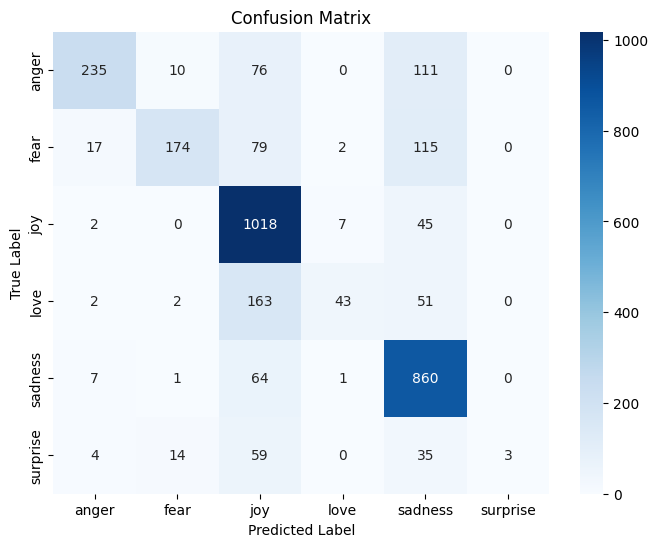

In [109]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(test_df['predicted_int'], test_df['label_int'])
print("Custom Metrics - Custom Naive Bayes")

print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.xlabel("Predicted Label")  
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Using Sklearn Metrics

Sklearn Metrics - Custom Model
Precision: 0.8269226828066216
Recall: 0.509302739210402
F1: 0.5322306330619936
Confusion Matrix:


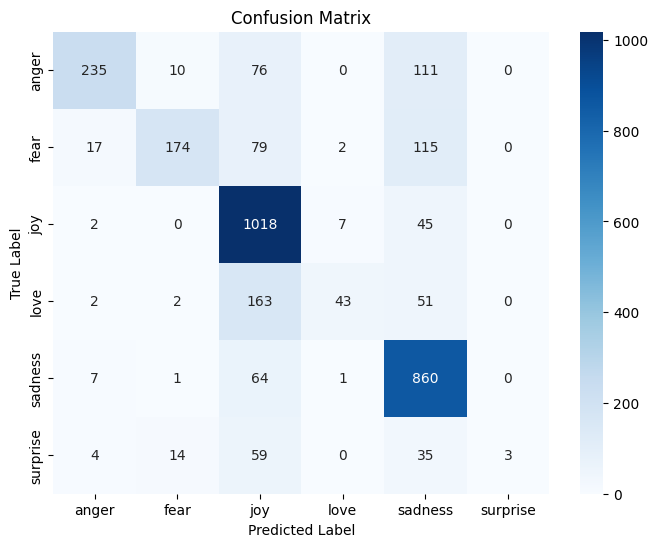

In [110]:
cm_sklearn = confusion_matrix(test_df['label'],test_df['predicted_label'])
print("Sklearn Metrics - Custom Model")
print("Precision:", precision_score(test_df['label'],test_df['predicted_label'], average='macro'))
print("Recall:", recall_score(test_df['label'],test_df['predicted_label'], average='macro'))
print("F1:", f1_score(test_df['label'],test_df['predicted_label'], average='macro'))
print("Confusion Matrix:")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sklearn, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Evaluation of Sklearn's

### Using Custiom Evaluation

In [111]:
test_df['sklearn_predicted_int'] = test_df['sklearn_predicted'].map(label_to_int)


Custom Metrics - Sklearn Naive Bayes
Precision: 0.8261598388412653
Recall: 0.5185254201472421
F1: 0.5439057918117013
Confusion Matrix:


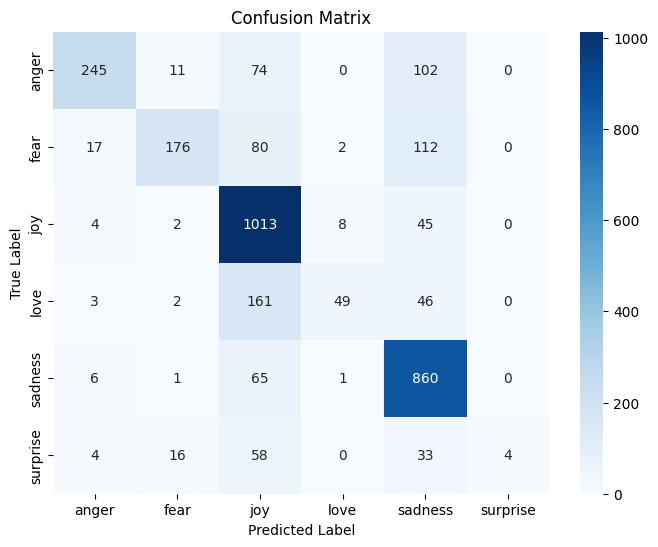

In [112]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(test_df['sklearn_predicted_int'], test_df['label_int'])
print("Custom Metrics - Sklearn Naive Bayes")
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.xlabel("Predicted Label")  
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


### Using Sklearn Metrics

Sklearn Metrics - Sklearn Model
Precision: 0.8261598388412653
Recall: 0.5185254201472421
F1: 0.5439057918117013
Confusion Matrix:


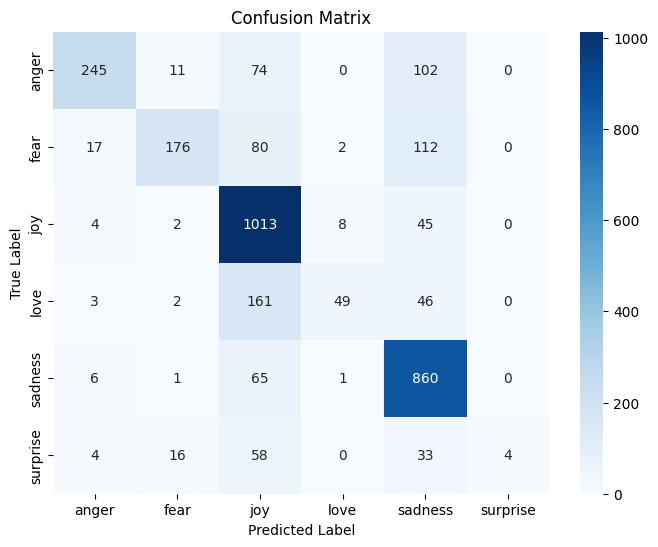

In [113]:
cm_sklearn = confusion_matrix(test_df['label'], test_df['sklearn_predicted'])
print("Sklearn Metrics - Sklearn Model")
print("Precision:", precision_score(test_df['label'], test_df['sklearn_predicted'], average='macro'))
print("Recall:", recall_score(test_df['label'], test_df['sklearn_predicted'], average='macro'))
print("F1:", f1_score(test_df['label'], test_df['sklearn_predicted'], average='macro'))
print("Confusion Matrix:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sklearn, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.xlabel("Predicted Label")  
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()